In [1]:
# %matplotlib widget
import numpy as np                          # numerical computing
import matplotlib.pyplot as plt             # plotting
import pandas as pd                         # data manipluation
import seaborn as sns

from sklearn.datasets import make_blobs     # synthetic cluster data
from sklearn.cluster import KMeans          # K-Means baseline
from sklearn.mixture import GaussianMixture # GMM from scikit-learn
from matplotlib.patches import Ellipse      # draw covariance ellipses
from scipy.spatial.distance import cdist    # pairwise distances
from scipy.stats import norm                # 1-D Gaussian pdf

plt.style.use("fivethirtyeight")
sns.set()
sns.set_context("talk")
%matplotlib inline

In [2]:
cod_df = pd.read_csv("./data/Multiple_Cause_of_Death_1999-2020-2.csv") # Multiple Causes of Death
adrd_df = pd.read_csv("./data/Accidental_Drug_Related_Deaths_2012-2024_20260423.csv") # State of Conneticut
nchs_df = pd.read_csv("./data/NCHS_-_Drug_Poisoning_Mortality_by_State__United_States_20260423.csv") # Drug poisoning by state

# [].unique()
cod_df.head(5)
# adrd_df['Sex'].unique()
# nchs_df['Race and Hispanic Origin'].unique()

,Notes,UCD - Drug/Alcohol Induced Cause,UCD - Drug/Alcohol Induced Cause Code,Sex,Sex Code,Race,Race Code,Year,Year Code,Ten-Year Age Groups,Ten-Year Age Groups Code,Deaths,Population,Crude Rate
0,NaN,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,F,American Indian or Alaska Native,1002-5,1999.0,1999.0,35-44 years,35-44,20.0,226197,8.8
1,NaN,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,F,American Indian or Alaska Native,1002-5,2000.0,2000.0,35-44 years,35-44,19.0,236235,Unreliable
2,NaN,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,F,American Indian or Alaska Native,1002-5,2001.0,2001.0,25-34 years,25-34,13.0,224905,Unreliable
3,NaN,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,F,American Indian or Alaska Native,1002-5,2001.0,2001.0,35-44 years,35-44,15.0,242881,Unreliable
4,NaN,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,F,American Indian or Alaska Native,1002-5,2001.0,2001.0,45-54 years,45-54,12.0,186923,Unreliable


In [3]:
## CLeaning Multiple Cause of Death dataframe
# Remove any columns with notes as they contain no information to our data 
# check = cod_df[cod_df["Notes"].notna()]
# print(check)
cleaned_cod_df = cod_df.iloc[:6235].drop(columns=["Notes"])

# Then clean our data so that we only include cases of drug deaths (so ignoring alchohl and other deaths)
cleaned_cod_df = cleaned_cod_df.rename(columns={"UCD - Drug/Alcohol Induced Cause": "Cause", "UCD - Drug/Alcohol Induced Cause Code": "Cause Codes"})
arr = cleaned_cod_df["Cause Codes"].unique()
# print(f"Array of unique cause codes: {arr}")
cleaned_cod_df = cleaned_cod_df[(cleaned_cod_df["Cause Codes"] == 'D1') | 
                        (cleaned_cod_df["Cause Codes"] == 'D2') | 
                        (cleaned_cod_df["Cause Codes"] == 'D3') | 
                        (cleaned_cod_df["Cause Codes"] == 'D4') | 
                        (cleaned_cod_df["Cause Codes"] == 'D9')]
# cleaned_df.info()
cleaned_cod_df = cleaned_cod_df.drop(columns=["Year Code", "Race Code", "Sex Code"])

# cleaned_cod_df[cleaned_cod_df['Population'] == 'Not Applicable']
cleaned_cod_df = cleaned_cod_df.drop([1008, 1034])
cleaned_cod_df['Population'] = cleaned_cod_df['Population'].astype(float)
cleaned_cod_df.head(5)

,Cause,Cause Codes,Sex,Race,Year,Ten-Year Age Groups,Ten-Year Age Groups Code,Deaths,Population,Crude Rate
0,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,1999.0,35-44 years,35-44,20.0,226197.0,8.8
1,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2000.0,35-44 years,35-44,19.0,236235.0,Unreliable
2,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,25-34 years,25-34,13.0,224905.0,Unreliable
3,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,35-44 years,35-44,15.0,242881.0,Unreliable
4,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,45-54 years,45-54,12.0,186923.0,Unreliable


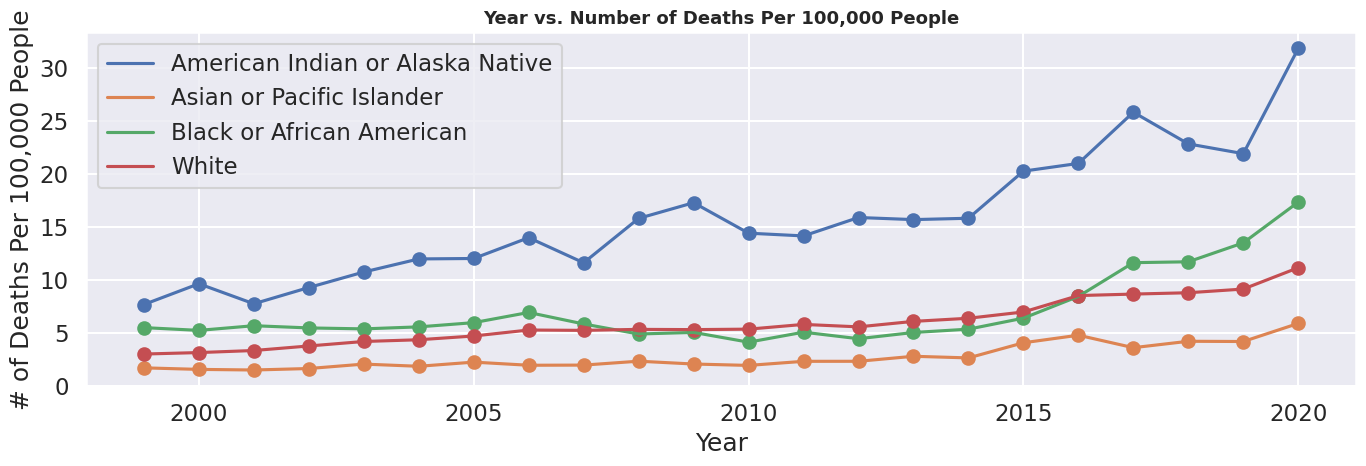

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

new_df = cleaned_cod_df[(cleaned_cod_df['Sex'] == 'Male')][['Year', 'Race', 'Sex', 'Deaths', 'Population']]

new_df = new_df.groupby(['Year', 'Race'], as_index=False).agg({'Deaths':'sum', 'Population':'sum'})

for race_var in new_df['Race'].unique():
    x1 = new_df[new_df['Race'] == race_var]["Year"]
    y1 = new_df[new_df['Race'] == race_var]["Deaths"] / new_df[new_df['Race'] == race_var]["Population"] * 100000
    axes.scatter(x1, y1)
    axes.plot(x1, y1, label=f'{race_var}')

axes.set_title("Year vs. Number of Deaths Per 100,000 People", fontweight='bold', fontsize=13)
axes.set_xlabel("Year")
axes.set_ylabel("# of Deaths Per 100,000 People")
axes.legend()
plt.tight_layout()
plt.show()

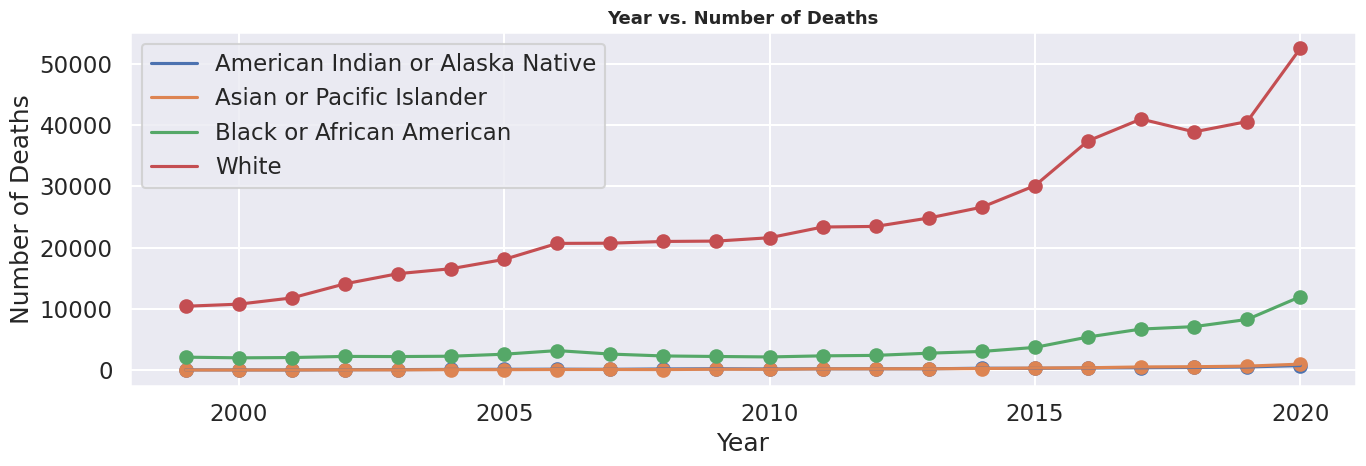

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

new_df = cleaned_cod_df[(cleaned_cod_df['Sex'] == 'Male')][['Year', 'Race', 'Sex', 'Deaths', 'Population']]

new_df = new_df.groupby(['Year', 'Race'], as_index=False).agg({'Deaths':'sum', 'Population':'sum'})

for race_var in new_df['Race'].unique():
    x1 = new_df[new_df['Race'] == race_var]["Year"]
    y1 = new_df[new_df['Race'] == race_var]["Deaths"]
    axes.scatter(x1, y1)
    axes.plot(x1, y1, label=f'{race_var}')

axes.set_title("Year vs. Number of Deaths", fontweight='bold', fontsize=13)
axes.set_xlabel("Year")
axes.set_ylabel("Number of Deaths")
axes.legend()
plt.tight_layout()
plt.show()

In [6]:
## CLeaning Accidental Drug Related Deaths dataframe
# cleaned_adrd_df = adrd_df[adrd_df["Sex"] == "Male"]
cleaned_adrd_df = adrd_df.sort_values(by='Date')
cleaned_adrd_df['Date'] = pd.to_datetime(cleaned_adrd_df['Date'])
cleaned_adrd_df = cleaned_adrd_df.dropna(subset=['Age'])
list_of_drugs = ['Heroin', 'Cocaine', 'Fentanyl', 
                 'Fentanyl Analogue', 'Oxycodone',
                 'Oxymorphone', 'Ethanol', 
                 'Hydrocodone', 'Benzodiazepine', 
                 'Methadone', 'Meth/Amphetamine', 
                 'Amphet', 'Tramad', 'Hydromorphone',
                 'Morphine (Not Heroin)', 'Xylazine', 
                 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 
                 'Other Opioid']

cleaned_adrd_df[list_of_drugs] = cleaned_adrd_df[list_of_drugs].fillna(0)
for drug in list_of_drugs:
    cleaned_adrd_df[f'{drug}'] = [1 if x == 'Y' else 0 for x in cleaned_adrd_df[f'{drug}']]

cleaned_adrd_df['Drug Count'] = cleaned_adrd_df[['Heroin', 'Cocaine', 'Fentanyl', 
                                                 'Fentanyl Analogue', 'Oxycodone',
                                                 'Oxymorphone', 'Ethanol', 
                                                 'Hydrocodone', 'Benzodiazepine', 
                                                 'Methadone', 'Meth/Amphetamine', 
                                                 'Amphet', 'Tramad', 'Hydromorphone',
                                                 'Morphine (Not Heroin)', 'Xylazine', 
                                                 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 
                                                 'Other Opioid']].sum(axis=1)
epoch = pd.to_datetime('2012-01-01')
cleaned_adrd_df['Days since 2012-Jan-01'] = (cleaned_adrd_df['Date']-epoch).dt.days
# df['status'] = ['Pass' if x >= 70 else 'Fail' for x in df['grade']]
# cleaned_adrd_df = cleaned_adrd_df[cleaned_adrd_df['Date Type'] == 'Date reported']
# cleaned_adrd_df['Cause of Death']
# cleaned_adrd_df['Date'].unique()
cleaned_adrd_df.info()
# cleaned_adrd_df

<class 'pandas.core.frame.DataFrame'>
Index: 12961 entries, 3026 to 12728
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           12961 non-null  datetime64[ns]
 1   Date Type                      12961 non-null  object        
 2   Age                            12961 non-null  float64       
 3   Sex                            12953 non-null  object        
 4   Race                           12896 non-null  object        
 5   Ethnicity                      3435 non-null   object        
 6   Residence City                 12319 non-null  object        
 7   Residence County               11654 non-null  object        
 8   Residence State                10926 non-null  object        
 9   Injury City                    12705 non-null  object        
 10  Injury County                  9526 non-null   object        
 11  Injury State     

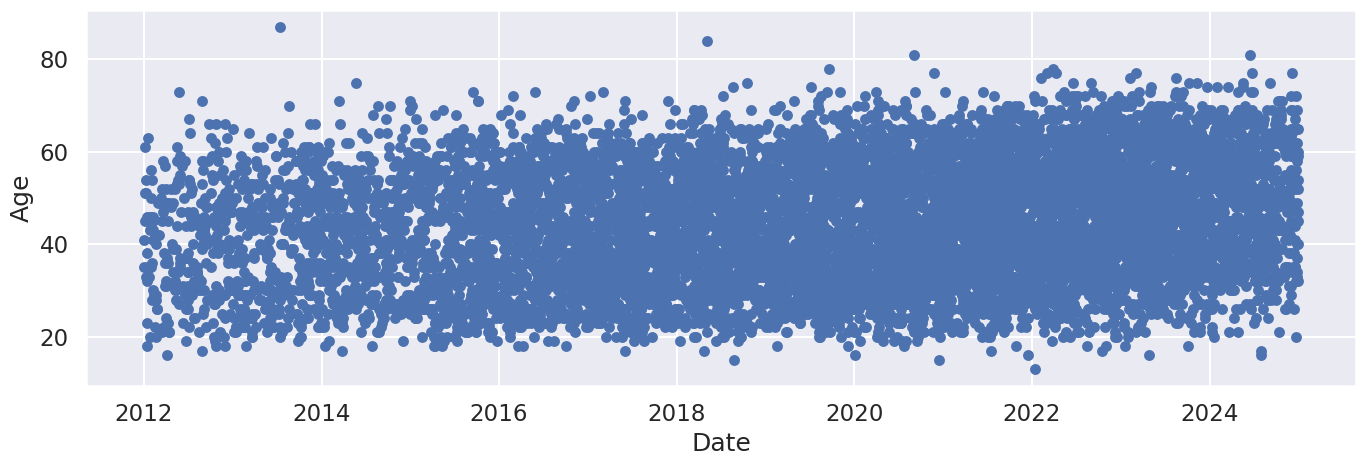

In [7]:
cleaned_adrd_df = cleaned_adrd_df[cleaned_adrd_df['Sex'] == 'Male']

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

x_vals = cleaned_adrd_df["Date"]
y_vals = cleaned_adrd_df["Age"]
axes.scatter(x_vals, y_vals, s=40)
axes.set_xlabel("Date")
axes.set_ylabel("Age")
plt.tight_layout()
plt.show()

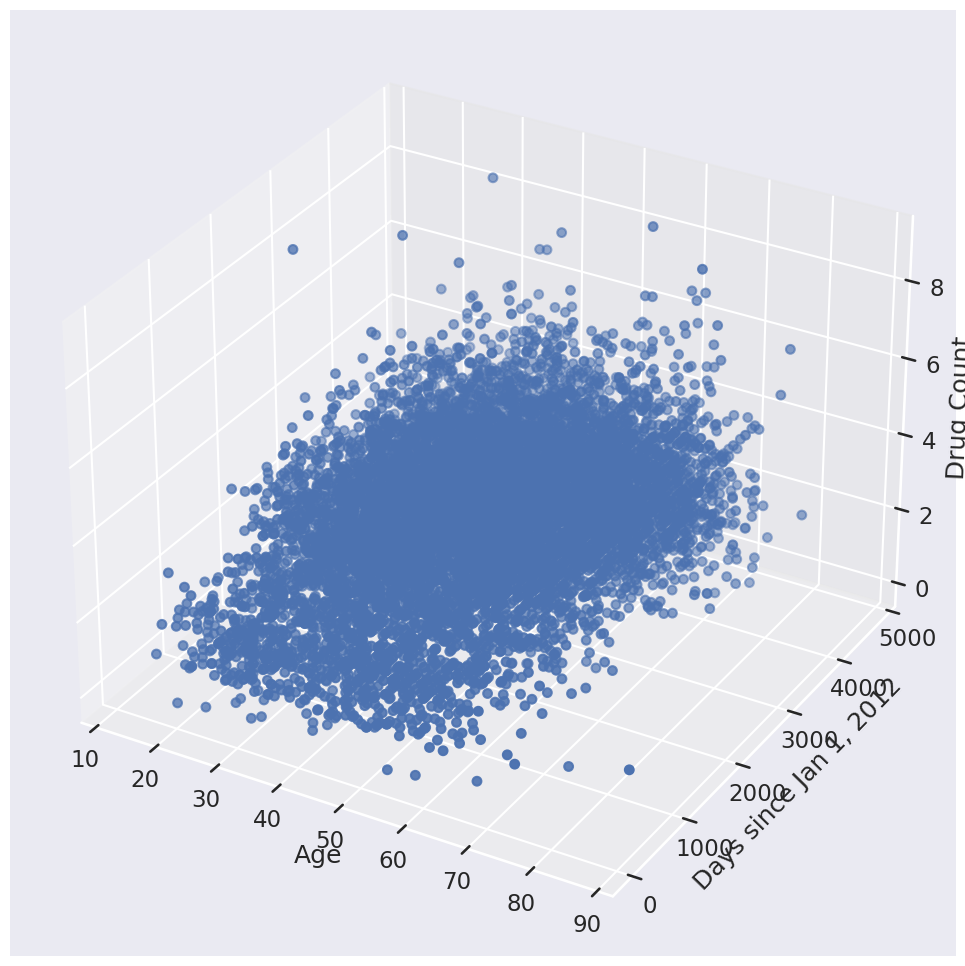

In [8]:
cleaned_adrd_df = cleaned_adrd_df[cleaned_adrd_df['Sex'] == 'Male']

fig = plt.figure(figsize=(10, 14))
axes = fig.add_subplot(projection='3d')

x_vals = cleaned_adrd_df["Age"]
y_vals = cleaned_adrd_df["Days since 2012-Jan-01"]
z_vals = cleaned_adrd_df["Drug Count"]

axes.scatter(x_vals, y_vals, z_vals, s=40)
axes.set_ylabel("Days since Jan 1, 2012")
axes.set_xlabel("Age")
axes.set_zlabel("Drug Count")

plt.tight_layout()
plt.show()

In [9]:
def draw_ellipse(ax, mean, cov, color, label=''):
    """
    Given a 2x2 covariance matrix, draw the ellipse that contains
    ~95% of the probability mass (2 standard deviations).
    """
    vals, vecs = np.linalg.eigh(cov)              # eigenvalues & eigenvectors
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))  # rotation angle
    w, h = 2 * 2 * np.sqrt(vals)                  # width/height at 2-sigma
    ell = Ellipse(xy=mean, width=w, height=h, angle=angle,
                  ec=color, fc=color, alpha=0.25, lw=2, label=label)
    ax.add_patch(ell)
    ax.plot(*mean, 'o', color=color, ms=8, zorder=5)  # mark the mean


# cleaned_adrd_df.info()

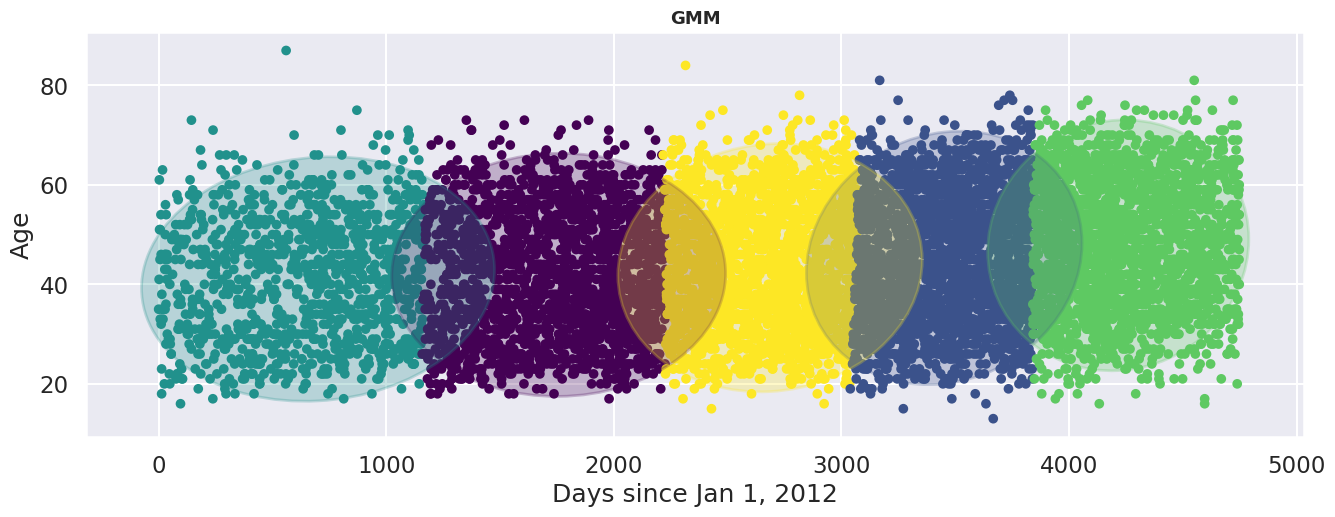

In [10]:
n = 5
gmm = GaussianMixture(n_components=n,        # K = n components
                       covariance_type='full', 
                       random_state=21)

labels_gmm = gmm.fit_predict(cleaned_adrd_df[['Days since 2012-Jan-01', 'Age']])

fig, axes = plt.subplots(1, 1, figsize=(14, 5))
axes.scatter(cleaned_adrd_df['Days since 2012-Jan-01'], cleaned_adrd_df['Age'], c=labels_gmm, s=30, cmap='viridis')
axes.set_xlabel("Days since Jan 1, 2012")
axes.set_ylabel("Age")
colors = plt.cm.viridis(np.linspace(0, 1, n))
for k in range(n):
#     # Overlay the learned covariance ellipse for each component
    draw_ellipse(axes, gmm.means_[k], gmm.covariances_[k], colors[k])
axes.set_title("GMM", fontweight='bold', fontsize=13);

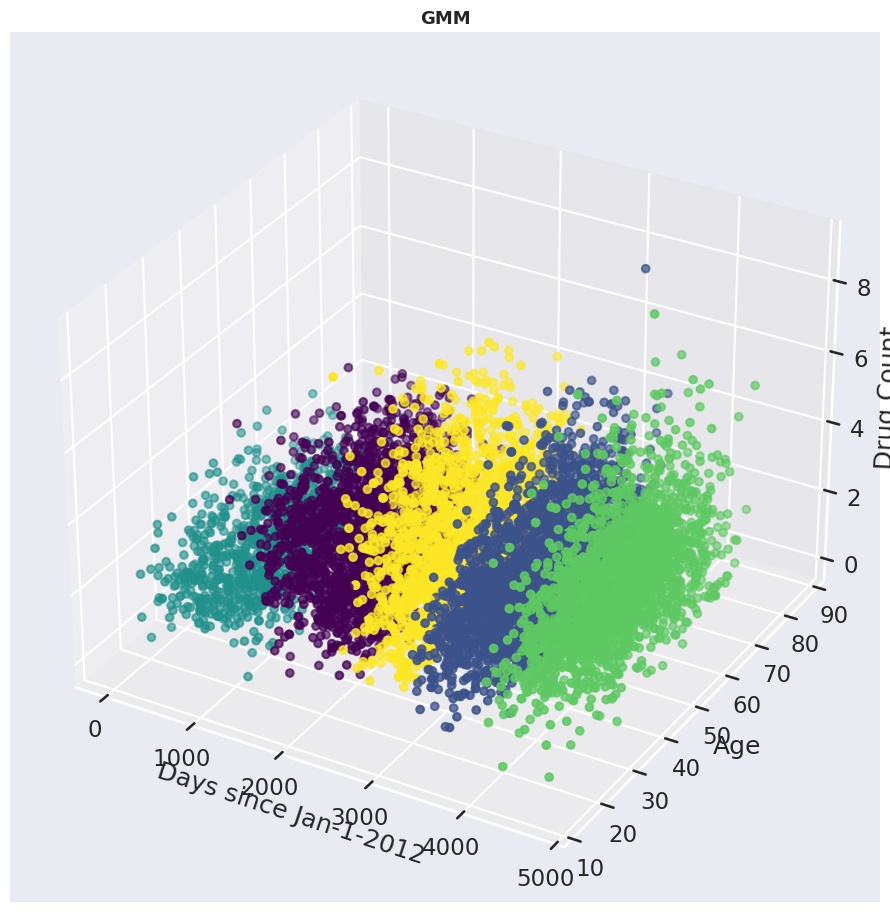

In [11]:
n = 5
gmm = GaussianMixture(n_components=n,        # K = n components
                       covariance_type='full', 
                       random_state=21)

labels_gmm = gmm.fit_predict(cleaned_adrd_df[['Days since 2012-Jan-01', 'Age', 'Drug Count']])

# fig, axes = plt.subplots(1, 1, figsize=(14, 5))
fig = plt.figure(figsize=(10, 14))
axes = fig.add_subplot(projection='3d')
axes.scatter(cleaned_adrd_df['Days since 2012-Jan-01'], cleaned_adrd_df['Age'], cleaned_adrd_df['Drug Count'], c=labels_gmm, s=30, cmap='viridis')
axes.set_xlabel("Days since Jan-1-2012")
axes.set_ylabel("Age")
axes.set_zlabel("Drug Count")
colors = plt.cm.viridis(np.linspace(0, 1, n))
# for k in range(n):
#     # Overlay the learned covariance ellipse for each component
    # draw_ellipse(axes, gmm.means_[k], gmm.covariances_[k], colors[k])
axes.set_title("GMM", fontweight='bold', fontsize=13);

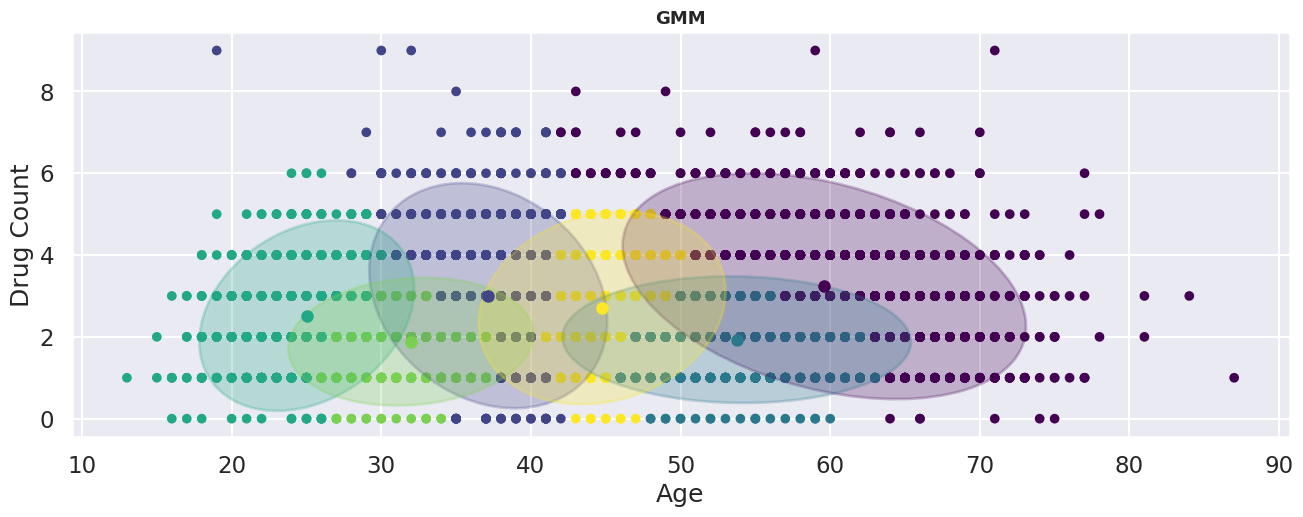

In [12]:
n = 6
gmm = GaussianMixture(n_components=n,        # K = n components
                       covariance_type='full', 
                       random_state=21)

labels_gmm = gmm.fit_predict(cleaned_adrd_df[['Age', 'Drug Count']])

fig, axes = plt.subplots(1, 1, figsize=(14, 5))
axes.scatter(cleaned_adrd_df['Age'], cleaned_adrd_df['Drug Count'], c=labels_gmm, s=30, cmap='viridis')
colors = plt.cm.viridis(np.linspace(0, 1, n))
axes.set_xlabel("Age")
axes.set_ylabel("Drug Count")
for k in range(n):
#     # Overlay the learned covariance ellipse for each component
    draw_ellipse(axes, gmm.means_[k], gmm.covariances_[k], colors[k])
axes.set_title("GMM", fontweight='bold', fontsize=13);

# Trying PCA Now

In [13]:
cleaned_cod_df

,Cause,Cause Codes,Sex,Race,Year,Ten-Year Age Groups,Ten-Year Age Groups Code,Deaths,Population,Crude Rate
0,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,1999.0,35-44 years,35-44,20.0,226197.0,8.8
1,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2000.0,35-44 years,35-44,19.0,236235.0,Unreliable
2,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,25-34 years,25-34,13.0,224905.0,Unreliable
3,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,35-44 years,35-44,15.0,242881.0,Unreliable
4,Drug poisonings (overdose) Unintentional (X40-...,D1,Female,American Indian or Alaska Native,2001.0,45-54 years,45-54,12.0,186923.0,Unreliable
...,...,...,...,...,...,...,...,...,...,...
2739,All other drug-induced causes,D9,Male,White,2020.0,45-54 years,45-54,518.0,15687816.0,3.3
2740,All other drug-induced causes,D9,Male,White,2020.0,55-64 years,55-64,550.0,16714227.0,3.3
2741,All other drug-induced causes,D9,Male,White,2020.0,65-74 years,65-74,249.0,12818362.0,1.9
2742,All other drug-induced causes,D9,Male,White,2020.0,75-84 years,75-84,70.0,6234692.0,1.1


In [14]:
male_cod_df = cleaned_cod_df[cleaned_cod_df['Sex'] == 'Male'][['Year', 'Race', 'Sex', 'Deaths', 'Population']]
male_cod_df = male_cod_df.groupby(['Year', 'Race'], as_index=False).agg({'Deaths':'sum', 'Population':'sum'})
male_cod_df['Crude Rate'] = male_cod_df["Deaths"] / male_cod_df["Population"] * 100000
male_cod_df

,Year,Race,Deaths,Population,Crude Rate
0,1999.0,American Indian or Alaska Native,62.0,807914.0,7.674084
1,1999.0,Asian or Pacific Islander,44.0,2608654.0,1.686694
2,1999.0,Black or African American,2138.0,38939874.0,5.490516
3,1999.0,White,10449.0,349226739.0,2.992039
4,2000.0,American Indian or Alaska Native,60.0,622562.0,9.637594
...,...,...,...,...,...
83,2019.0,White,40594.0,444316732.0,9.136275
84,2020.0,American Indian or Alaska Native,765.0,2399255.0,31.884898
85,2020.0,Asian or Pacific Islander,997.0,16936541.0,5.886680
86,2020.0,Black or African American,12005.0,69166586.0,17.356647


In [15]:
pca_matrix = male_cod_df.pivot(index='Year', columns='Race', values='Crude Rate')
# pca_matrix = male_cod_df.pivot(index='Race', columns='Year', values='Crude Rate')
pca_matrix

Race,American Indian or Alaska Native,Asian or Pacific Islander,Black or African American,White
Year,,,,
1999.0,7.674084,1.686694,5.490516,2.992039
2000.0,9.637594,1.541189,5.228323,3.131211
2001.0,7.744686,1.483248,5.670095,3.325728
2002.0,9.280675,1.623383,5.460956,3.754879
2003.0,10.746835,2.040972,5.371474,4.178990
2004.0,11.983192,1.834887,5.560169,4.342515
2005.0,12.025327,2.227571,5.959982,4.698612
2006.0,13.992385,1.932320,6.923141,5.263352
2007.0,11.620831,1.947062,5.835011,5.229497


In [16]:
row_means = pca_matrix.mean(axis=1)
print(row_means)
# Leaving out the 
# A_matrix = pca_matrix
A_matrix = pca_matrix.sub(row_means, axis=0)
A_matrix

Year
1999.0     4.460833
2000.0     4.884579
2001.0     4.555939
2002.0     5.029973
2003.0     5.584568
2004.0     5.930191
2005.0     6.227873
2006.0     7.027800
2007.0     6.158100
2008.0     7.085782
2009.0     7.421218
2010.0     6.448968
2011.0     6.828281
2012.0     7.052377
2013.0     7.397988
2014.0     7.543535
2015.0     9.423311
2016.0    10.686412
2017.0    12.434745
2018.0    11.889458
2019.0    12.188412
2020.0    16.570289
dtype: float64


Race,American Indian or Alaska Native,Asian or Pacific Islander,Black or African American,White
Year,,,,
1999.0,3.213251,-2.774140,1.029683,-1.468794
2000.0,4.753015,-3.343390,0.343743,-1.753368
2001.0,3.188747,-3.072691,1.114156,-1.230211
2002.0,4.250702,-3.406590,0.430983,-1.275095
2003.0,5.162267,-3.543596,-0.213094,-1.405578
2004.0,6.053002,-4.095304,-0.370022,-1.587676
2005.0,5.797454,-4.000302,-0.267891,-1.529261
2006.0,6.964586,-5.095480,-0.104658,-1.764448
2007.0,5.462731,-4.211038,-0.323090,-0.928603


In [17]:
U,S,Vt = np.linalg.svd(A_matrix)
Sd = np.zeros(A_matrix.shape)
np.fill_diagonal(Sd,S)
np.allclose(U@Sd@Vt, A_matrix)
# S

True

In [18]:
# Finding covariance matrix
# N = A_matrix.size
N = 4
print(f'Number of Data points: {N}\n')

C = U@((1/N)*Sd@Sd.T)@U.T
e_val, e_vec = np.linalg.eig(C)

var_prin_components = np.array(e_val)
tot_var = e_val.sum()
frac_tot_var = (var_prin_components[0]+var_prin_components[1])/tot_var

print(f'The variances in the principle components: {var_prin_components}\n')
print(f'Total Variance of A: {tot_var}\n')
print(f'Fraction of the total variance of the first component: {var_prin_components[0]/tot_var}\n')
print(f'Fraction of the total variance of the second component: {var_prin_components[1]/tot_var}\n')
print(f'Fraction of the total variance of the first two components: {frac_tot_var}\n')

Number of Data points: 4

The variances in the principle components: [ 5.93777706e+02+0.00000000e+00j  1.32017696e+01+0.00000000e+00j
  7.88723268e-01+0.00000000e+00j -1.96936535e-14+0.00000000e+00j
  1.59511133e-14+0.00000000e+00j -1.29045647e-14+0.00000000e+00j
 -6.56588610e-15+7.92992650e-15j -6.56588610e-15-7.92992650e-15j
 -7.88161165e-15+2.01385682e-15j -7.88161165e-15-2.01385682e-15j
 -4.92050803e-15+0.00000000e+00j -3.53741004e-15+1.25256862e-15j
 -3.53741004e-15-1.25256862e-15j  8.74696888e-15+0.00000000e+00j
  7.21199960e-15+0.00000000e+00j  6.31035175e-15+4.67078131e-16j
  6.31035175e-15-4.67078131e-16j  1.11982659e-15+9.50279419e-16j
  1.11982659e-15-9.50279419e-16j  2.84926401e-16+0.00000000e+00j
  3.29102548e-15+0.00000000e+00j  2.65435960e-15+0.00000000e+00j]

Total Variance of A: (607.7681992554104-5.9164567891575885e-31j)

Fraction of the total variance of the first component: (0.976980544727415+9.510637746115898e-34j)

Fraction of the total variance of the second comp

In [19]:
gamma = np.array(U.T@A_matrix)
# gamma = np.array(U@Sd)
# gamma = np.array(A_matrix @ Vt)
print(gamma)

[[-3.99415383e+01  2.57176459e+01  4.17702886e+00  1.00468635e+01]
 [-1.53433041e+00 -2.54888944e+00  6.26178345e+00 -2.17856360e+00]
 [-3.26233495e-01 -1.04856140e+00 -2.11056413e-02  1.39590054e+00]
 [-2.67463949e-15  1.10981360e-15  4.08004115e-15  4.07643775e-15]
 [ 1.63589345e-16  1.21448024e-15  1.80856188e-16  1.60011179e-16]
 [ 2.28462289e-15 -6.55796002e-16 -1.31400423e-16 -2.53829167e-16]
 [ 7.27300116e-16 -6.22751837e-17  2.71481606e-17 -8.94772615e-17]
 [-1.62840473e-15  1.31062284e-15  1.04658025e-16  1.95036649e-16]
 [ 1.22052162e-15 -3.20416372e-16 -3.78128759e-16  5.83098862e-17]
 [ 1.62508430e-15  7.85155395e-16 -1.97013204e-17  2.40131239e-16]
 [-3.53436855e-16  1.89125397e-15 -1.04295044e-17  7.17033964e-17]
 [-1.87557377e-20  5.14036688e-17 -7.92577761e-17  2.88920863e-17]
 [ 2.09067887e-15 -5.78036682e-16 -4.45850573e-16  1.21681427e-16]
 [ 2.54855830e-15 -6.00530115e-16 -6.28396952e-16 -3.34642297e-16]
 [-1.88441726e-16  7.54124351e-17  4.22085338e-16 -3.55839394e

In [20]:
gamma_2 = gamma[0:2]
proj = pd.DataFrame((gamma_2).T, columns=[0,1])
proj['Race'] = pca_matrix.columns
proj  


,0,1,Race
0,-39.941538,-1.534330,American Indian or Alaska Native
1,25.717646,-2.548889,Asian or Pacific Islander
2,4.177029,6.261783,Black or African American
3,10.046863,-2.178564,White


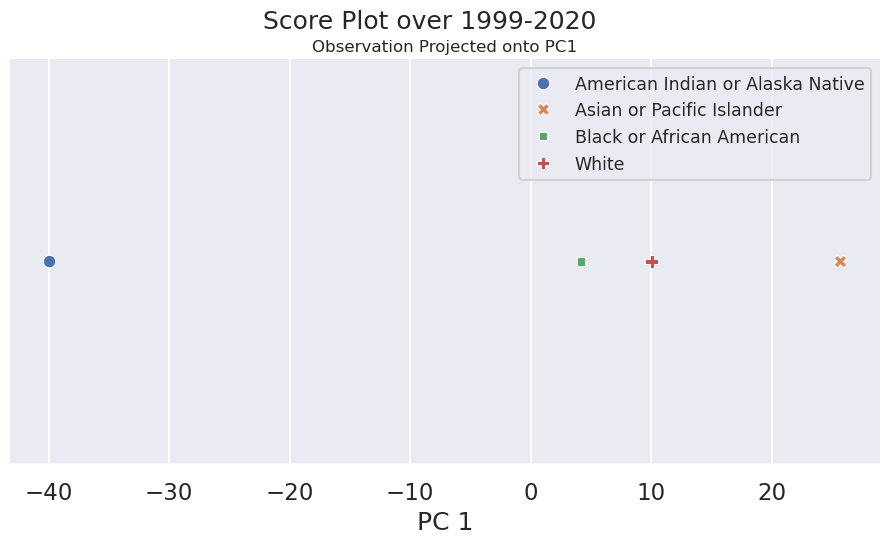

In [21]:
fig = plt.figure(figsize=(10,5))
ax = plt.gca()
plt.suptitle("Score Plot over 1999-2020", fontsize=18)
plt.title("Observation Projected onto PC1", fontsize=12)

plt.xlabel("PC 1")
# plt.ylabel("PC 2")
# ax.set_aspect(1)
# sns.scatterplot(x = 0, y=1, hue='Race', style='Race', data=proj, ax=ax)
sns.scatterplot(x = proj.iloc[0:4][0], y=0*proj.iloc[0:4][0], hue='Race', style='Race', data=proj, ax=ax)
plt.gca().get_yaxis().set_visible(False)  # Hide Y-axis
sns.despine(left=True)
plt.legend(fontsize='x-small', title_fontsize='5')
plt.show()

In [22]:
# -------------------------- ------

In [23]:
pre_2013_matrix = pca_matrix.loc[[1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,], :]
pre_2013_matrix

Race,American Indian or Alaska Native,Asian or Pacific Islander,Black or African American,White
Year,,,,
1999.0,7.674084,1.686694,5.490516,2.992039
2000.0,9.637594,1.541189,5.228323,3.131211
2001.0,7.744686,1.483248,5.670095,3.325728
2002.0,9.280675,1.623383,5.460956,3.754879
2003.0,10.746835,2.040972,5.371474,4.178990
2004.0,11.983192,1.834887,5.560169,4.342515
2005.0,12.025327,2.227571,5.959982,4.698612
2006.0,13.992385,1.932320,6.923141,5.263352
2007.0,11.620831,1.947062,5.835011,5.229497


In [24]:
post_2013_matrix = pca_matrix.loc[[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020], :]
post_2013_matrix

Race,American Indian or Alaska Native,Asian or Pacific Islander,Black or African American,White
Year,,,,
2013.0,15.701425,2.780605,5.029752,6.080171
2014.0,15.828669,2.626281,5.344128,6.375063
2015.0,20.282330,4.057678,6.384086,6.969149
2016.0,21.013112,4.772126,8.440056,8.520354
2017.0,25.853855,3.593685,11.630702,8.660737
2018.0,22.857804,4.199262,11.713441,8.787327
2019.0,21.936445,4.176656,13.504271,9.136275
2020.0,31.884898,5.886680,17.356647,11.152933


In [25]:
# row_means_pre = pre_2013_matrix.mean(axis=1)
# row_means_post = post_2013_matrix.mean(axis=1)
# A_matrix_pre = pre_2013_matrix.sub(row_means_pre, axis=0)
# A_matrix_post = post_2013_matrix.sub(row_means_post, axis=0)
A_matrix_pre = pre_2013_matrix
A_matrix_post = post_2013_matrix

print(A_matrix_pre)
print()
print(A_matrix_post)

Race    American Indian or Alaska Native  Asian or Pacific Islander  \
Year                                                                  
1999.0                          7.674084                   1.686694   
2000.0                          9.637594                   1.541189   
2001.0                          7.744686                   1.483248   
2002.0                          9.280675                   1.623383   
2003.0                         10.746835                   2.040972   
2004.0                         11.983192                   1.834887   
2005.0                         12.025327                   2.227571   
2006.0                         13.992385                   1.932320   
2007.0                         11.620831                   1.947062   
2008.0                         15.817162                   2.315782   
2009.0                         17.297849                   2.048530   
2010.0                         14.418208                   1.917512   
2011.0

In [26]:
U_pre,S_pre,Vt_pre = np.linalg.svd(A_matrix_pre)
Sd_pre = np.zeros(A_matrix_pre.shape)
np.fill_diagonal(Sd_pre, S_pre)
np.allclose(U_pre@Sd_pre@Vt_pre, A_matrix_pre)

True

In [27]:
U_post,S_post,Vt_post = np.linalg.svd(A_matrix_post)
Sd_post = np.zeros(A_matrix_post.shape)
np.fill_diagonal(Sd_post, S_post)
np.allclose(U_post@Sd_post@Vt_post, A_matrix_post)

True

In [28]:
# gamma_pre = np.array(U_pre@Sd_pre)
gamma_pre =  np.array(U_pre.T@A_matrix_pre)
gamma2_pre = gamma_pre[0:2]

proj_pre = pd.DataFrame((gamma2_pre).T, columns=[0,1])
proj_pre['Race'] = pca_matrix.columns
proj_pre

,0,1,Race
0,-47.303926,2.263804,American Indian or Alaska Native
1,-7.294353,-0.525254,Asian or Pacific Islander
2,-19.556981,-5.063298,Black or African American
3,-17.465146,-0.242345,White


In [29]:
# gamma_post = np.array(U_pre@Sd_pre)
gamma_post =  np.array(U_post.T@A_matrix_post)
gamma2_post = gamma_post[0:2]

proj_post = pd.DataFrame((gamma2_post).T, columns=[0,1])
# male_cod_df['Race'].iloc[14:25]
proj_post['Race'] = pca_matrix.columns
proj_post

,0,1,Race
0,-63.511310,2.125185,American Indian or Alaska Native
1,-11.583391,0.518919,Asian or Pacific Islander
2,-29.909643,-5.230456,Black or African American
3,-23.575530,0.655635,White


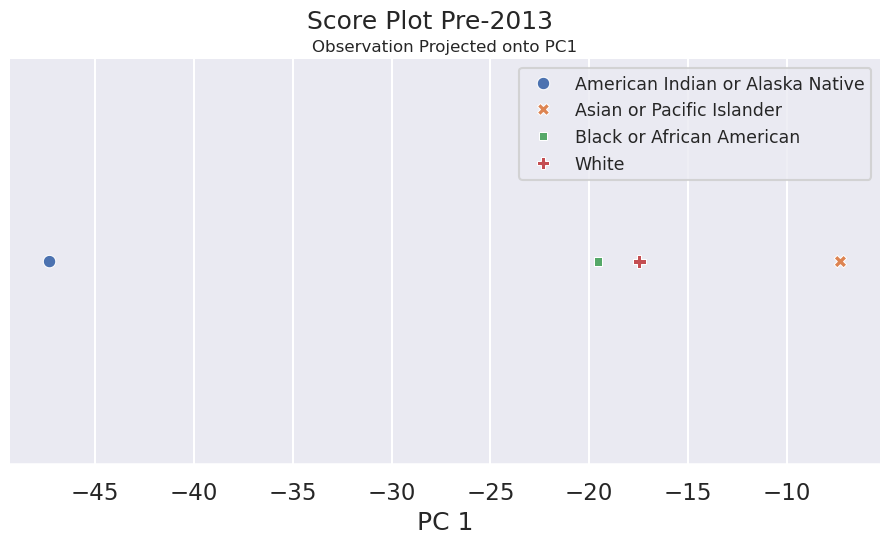

In [30]:
fig = plt.figure(figsize=(10,5))
ax = plt.gca()
plt.suptitle("Score Plot Pre-2013", fontsize=18)
plt.title("Observation Projected onto PC1", fontsize=12)
plt.xlabel("PC 1")
sns.scatterplot(x = proj_pre.iloc[0:4][0], y=0*proj_pre.iloc[0:4][0], hue='Race', style='Race', data=proj_pre, ax=ax)
plt.gca().get_yaxis().set_visible(False)  # Hide Y-axis
sns.despine(left=True)
plt.legend(fontsize='x-small', title_fontsize='5')
plt.show()

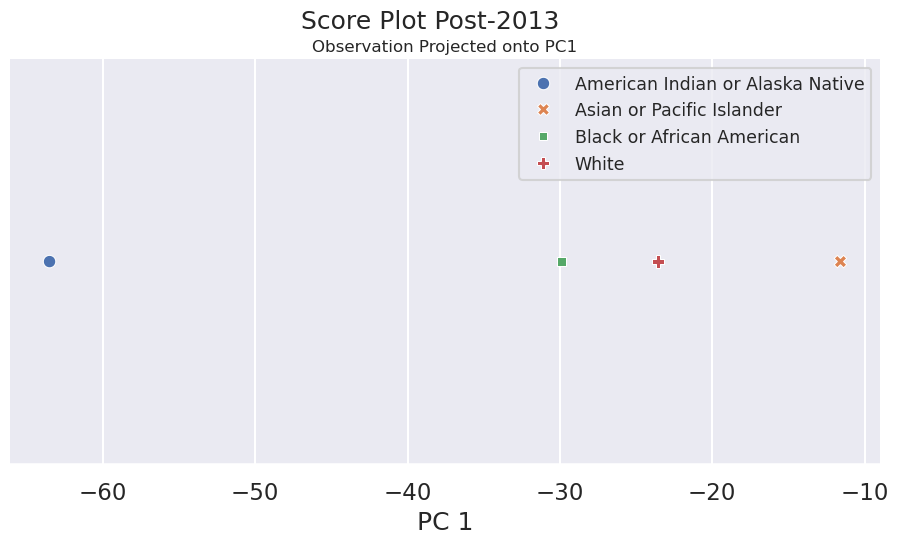

In [31]:
fig = plt.figure(figsize=(10,5))
ax = plt.gca()
plt.suptitle("Score Plot Post-2013", fontsize=18)
plt.title("Observation Projected onto PC1", fontsize=12)
plt.xlabel("PC 1")
sns.scatterplot(x = proj_post.iloc[0:4][0], y=0*proj_post.iloc[0:4][0], hue='Race', style='Race', data=proj_post, ax=ax)
plt.gca().get_yaxis().set_visible(False)  # Hide Y-axis
sns.despine(left=True)
plt.legend(fontsize='x-small', title_fontsize='5')
plt.show()

In [32]:
difference_in_pc1s= proj_post.loc[:, ['Race']]
# difference_in_pc1s['Difference'] = np.abs(proj_pre[0]-proj_post[0])
difference_in_pc1s['Difference'] = proj_pre[0]-proj_post[0]
difference_in_pc1s

,Race,Difference
0,American Indian or Alaska Native,16.207384
1,Asian or Pacific Islander,4.289038
2,Black or African American,10.352662
3,White,6.110384


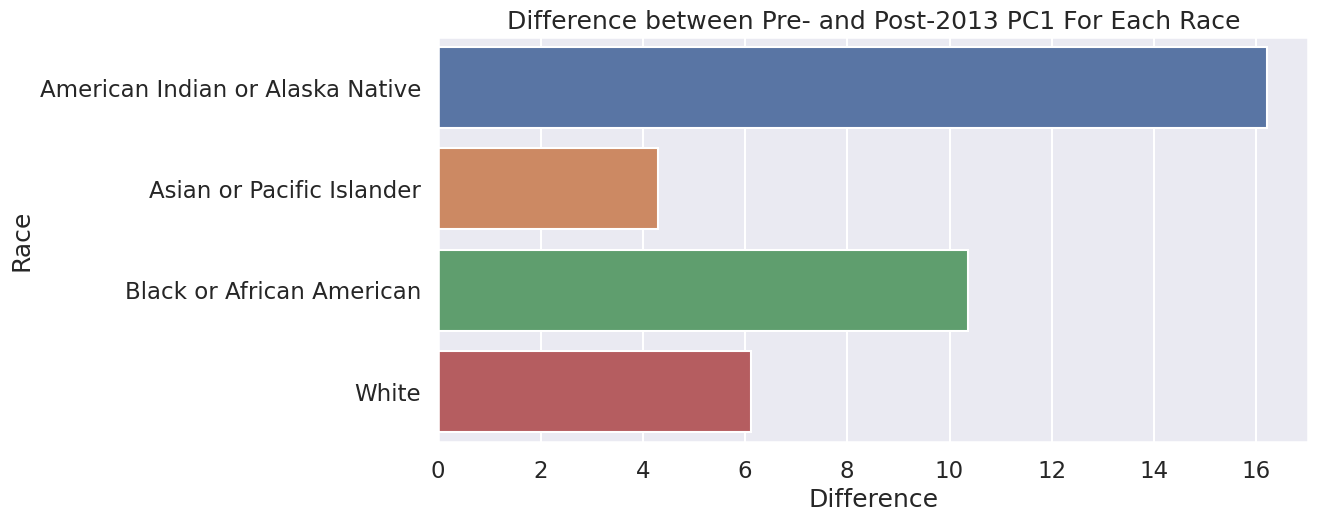

In [33]:
fig = plt.figure(figsize=(10,5))
ax = plt.gca()
# plt.xlabel("PC 1")
# plt.suptitle("")
plt.title("Difference between Pre- and Post-2013 PC1 For Each Race")
sns.barplot(difference_in_pc1s, x='Difference', y='Race', hue='Race');